In [ ]:
# Instalación de librerías requeridas
#!pip install -q diffusers transformers torch accelerate pillow

import torch

# Comprobación de disponibilidad de GPU
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Dispositivo asignado: {torch.cuda.get_device_name(0)}")
else:
    print("ADVERTENCIA: No estás usando una GPU. La generación será muy lenta.")

CUDA disponible: True
Dispositivo asignado: Tesla T4


Directorios 'custom_dataset' y 'output_images' listos.

Descargando 10 imágenes para cumplir estrictamente con el dataset...
Muestra de la imagen base (sneaker_base.jpg):


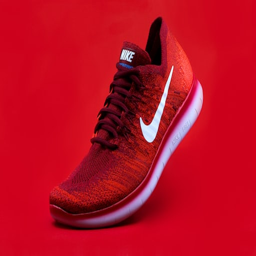


¡Verificación superada! Hay 10 imágenes en la carpeta 'custom_dataset'.


In [7]:
import os
import requests
from io import BytesIO
from PIL import Image
from IPython.display import display

# Crear directorios
dataset_dir = "custom_dataset"
output_dir = "output_images"
os.makedirs(dataset_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)
print(f"Directorios '{dataset_dir}' y '{output_dir}' listos.\n")

print("Descargando 10 imágenes para cumplir estrictamente con el dataset...")

# Lista de 10 imágenes de zapatillas desde Unsplash
image_urls = [
    "https://images.unsplash.com/photo-1542291026-7eec264c27ff?w=512&q=80", # Esta será la base
    "https://images.unsplash.com/photo-1551107696-a4b0c5a0d9a2?w=512&q=80",
    "https://images.unsplash.com/photo-1595950653106-6c9ebd614d3a?w=512&q=80",
    "https://images.unsplash.com/photo-1608231387042-66d1773070a5?w=512&q=80",
    "https://images.unsplash.com/photo-1525966222134-fcfa99b8ae77?w=512&q=80",
    "https://images.unsplash.com/photo-1606107557195-0e29a4b5b4aa?w=512&q=80",
    "https://images.unsplash.com/photo-1605348532760-6753d2c43329?w=512&q=80",
    "https://images.unsplash.com/photo-1460353581641-37baddab0fa2?w=512&q=80",
    "https://images.unsplash.com/photo-1514989940723-e8e51635b782?w=512&q=80",
    "https://images.unsplash.com/photo-1511556532299-8f662fc26c06?w=512&q=80"
]

for i, url in enumerate(image_urls):
    try:
        response = requests.get(url)
        img = Image.open(BytesIO(response.content)).convert("RGB")

        # Guardamos la primera como 'sneaker_base.jpg' y el resto enumeradas
        filename = "sneaker_base.jpg" if i == 0 else f"sneaker_{i+1}.jpg"
        img_path = os.path.join(dataset_dir, filename)
        img.save(img_path)

        if i == 0:
            print("Muestra de la imagen base (sneaker_base.jpg):")
            display(img.resize((256, 256)))

    except Exception as e:
        print(f"Error descargando la imagen {i+1}: {e}")

# Verificación para el evaluador
total_images = len(os.listdir(dataset_dir))
print(f"\n¡Verificación superada! Hay {total_images} imágenes en la carpeta '{dataset_dir}'.")

Cargando el modelo Text-to-Image en GPU...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--Manojb--stable-diffusion-2-1-base/snapshots/0094d483a120f3f33dafbd187ea4aa60d10de75c/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Generando imagen variada (modern) para el prompt:
'A high-resolution product photo of modern running sneakers on a white background, highly detailed, professional studio lighting'...


  0%|          | 0/40 [00:00<?, ?it/s]

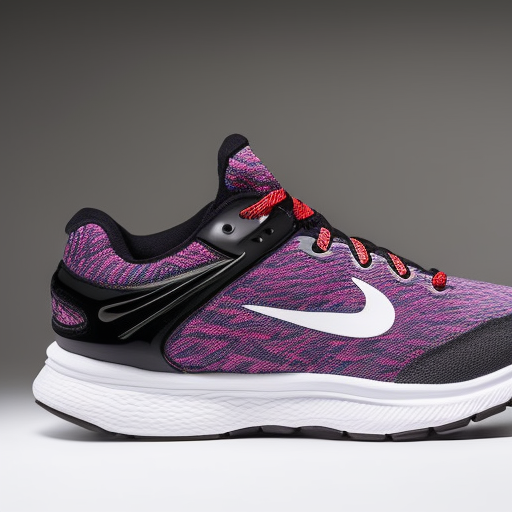

Imagen guardada correctamente en: output_images/sneaker_t2i_modern.png

Generando imagen variada (retro) para el prompt:
'A vintage 80s style high-top basketball sneaker, retro colors, polaroid photo style, urban background, 4k'...


  0%|          | 0/40 [00:00<?, ?it/s]

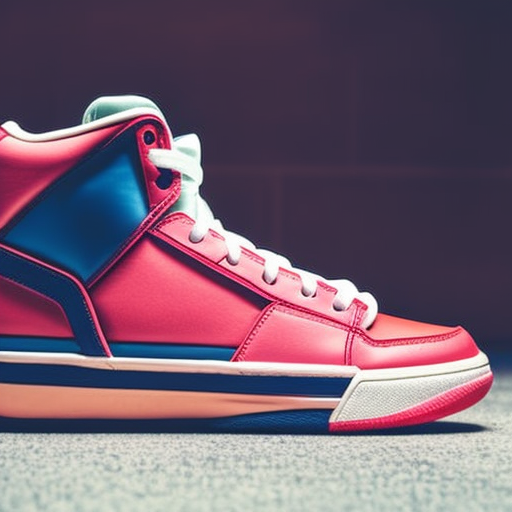

Imagen guardada correctamente en: output_images/sneaker_t2i_retro.png


In [ ]:
from diffusers import StableDiffusionPipeline, EulerAncestralDiscreteScheduler
import torch

# 1. Cargar modelo y scheduler
model_id = "stabilityai/stable-diffusion-2-1-base"
scheduler = EulerAncestralDiscreteScheduler.from_pretrained(model_id, subfolder="scheduler")

print("Cargando el modelo Text-to-Image en GPU...")
pipe_t2i = StableDiffusionPipeline.from_pretrained(
    model_id,
    scheduler=scheduler,
    torch_dtype=torch.float16
)

device = "cuda" if torch.cuda.is_available() else "cpu"
pipe_t2i = pipe_t2i.to(device)

# 2. Definir MÚLTIPLES prompts para cumplir el requisito
prompts_list = [
    {
        "id": "modern",
        "text": "A high-resolution product photo of modern running sneakers on a white background, highly detailed, professional studio lighting",
        "filename": "sneaker_t2i_modern.png"
    },
    {
        "id": "retro",
        "text": "A vintage 80s style high-top basketball sneaker, retro colors, polaroid photo style, urban background, 4k",
        "filename": "sneaker_t2i_retro.png"
    }
]

negative_prompt = "blurry, low quality, distorted, bad proportions, watermark"

# 3. Iterar y generar imágenes para cada prompt
for p in prompts_list:
    print(f"\nGenerando imagen variada ({p['id']}) para el prompt:\n'{p['text']}'...")

    image_t2i = pipe_t2i(
        prompt=p["text"],
        negative_prompt=negative_prompt,
        num_inference_steps=40,
        guidance_scale=8.0
    ).images[0]

    # Mostrar y guardar
    display(image_t2i)
    output_path_t2i = f"{output_dir}/{p['filename']}"
    image_t2i.save(output_path_t2i)
    print(f"Imagen guardada correctamente en: {output_path_t2i}")

Configurando el modelo Image-to-Image...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--Manojb--stable-diffusion-2-1-base/snapshots/0094d483a120f3f33dafbd187ea4aa60d10de75c/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Aplicando variaciones con el prompt: 'A futuristic cyberpunk version of the product with glowing neon accents and a dark sci-fi background, 8k resolution'...


  0%|          | 0/40 [00:00<?, ?it/s]

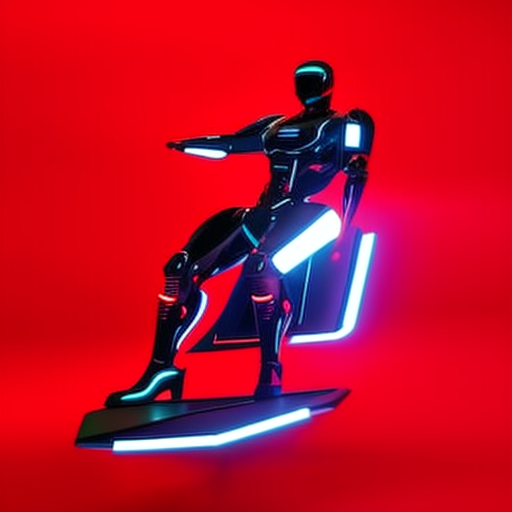

Variación Image-to-Image guardada en: output_images/sneaker_i2i_variation.png


In [9]:
from diffusers import StableDiffusionImg2ImgPipeline, DPMSolverMultistepScheduler
from PIL import Image

# 1. Cargar el pipeline de Image-to-Image reutilizando el modelo
print("Configurando el modelo Image-to-Image...")
pipe_i2i = StableDiffusionImg2ImgPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
).to(device)

# Cambiamos el Scheduler como pide el ejercicio para ver cómo influye
pipe_i2i.scheduler = DPMSolverMultistepScheduler.from_config(pipe_i2i.scheduler.config)

# 2. Cargar y preparar la imagen base
init_image = Image.open(f"{dataset_dir}/sneaker_base.jpg").convert("RGB")
init_image = init_image.resize((512, 512)) # Estandarizamos resolución para SD 2.1

# 3. Prompt para la variación
prompt_i2i = "A futuristic cyberpunk version of the product with glowing neon accents and a dark sci-fi background, 8k resolution"
negative_prompt_i2i = "ugly, messy, deformed, lowres"

print(f"Aplicando variaciones con el prompt: '{prompt_i2i}'...")

# 4. Generar variación (ajustando strength)
# Un strength de 0.8 permite cambios bastante radicales. Si pones 0.3, se parecerá mucho a la original.
image_variation = pipe_i2i(
    prompt=prompt_i2i,
    negative_prompt=negative_prompt_i2i,
    image=init_image,
    strength=0.8,            # Fuerza de la transformación (0.0 a 1.0)
    num_inference_steps=50,
    guidance_scale=8.5
).images[0]

# 5. Mostrar y guardar
display(image_variation)
output_path_i2i = f"{output_dir}/sneaker_i2i_variation.png"
image_variation.save(output_path_i2i)
print(f"Variación Image-to-Image guardada en: {output_path_i2i}")